In [3]:
import matplotlib.pyplot as plt
from qutip import *
import numpy as np
import scipy.integrate as integrate
from scipy.ndimage import gaussian_filter1d

# For optimization/visualizations
import optuna
from optuna.visualization import plot_optimization_history, plot_contour, plot_param_importances

from tqdm import tqdm

In [4]:
%run three_level_freespace_funcs.py
from three_level_freespace_funcs import three_level_simulation, plot_probs

# Summary 
$$ \hat{H} = g_{ge} \alpha(t)(\hat{\sigma}_{ge}+ \hat{\sigma}_{eg}) +
g_{se} (\beta(t)\hat{\sigma}_{se} + \beta^\dagger(t)\hat{\sigma}_{es}) + \Delta \hat{\sigma}_{ee}$$

$$  \mathbf{L} = \begin{bmatrix} -{g_{ge}^*}\hat{\sigma}_{eg}, -\frac{1}{\sqrt{C}}{g_{ge}^*}\hat{\sigma}_{eg} \end{bmatrix} $$

$$\Omega_{\text{Gorshkov}}(t)=\frac{\Omega(t)}{2}= -\frac{\gamma(1+C)-i\Delta}{\sqrt{2\gamma(1+C)}} \cdot \frac{\alpha_{in}(t)}{\sqrt{\int_0^t{|\alpha_{in}(t)|^2 dt}}} \cdot \text{exp} \left(\frac{i \Delta \cdot h(t, T)}{\gamma^2(1+C)^2+\Delta^2} \right) = a\times b \times \text{exp} (\frac{i \Delta \cdot h(t, T)}{c})$$

-  From the cooperativity document, $g_{ge} = \sqrt{2\gamma C}$ in free space. Note $2\gamma = \Gamma$.
- Gorshkov writes the Rabi frequency in amplitude units, which is why it is scaled by 2. Physically, the $\frac{1}{2}$ in $\Omega(t)$ comes from removing the higher-frequency term in RWA - derived from dipole moment/electric field

$$ \hat{H} = g_{ge} \alpha(t)(\hat{\sigma}_{ge}+ \hat{\sigma}_{eg}) + \left(\frac{\Omega(t)}{2}\hat{\sigma}_{se} + \frac{\Omega(t)}{2}^\dagger\hat{\sigma}_{es}\right) + \Delta \hat{\sigma}_{ee}$$
- $\Omega(t)$ is the effective Rabi frequency, which already accounts for $g_{se}$ in the $\gamma, C$ terms included in $\Omega(t)$. $g_{se}$ is set to $1$ right now, which is why this works, so in the code $\Omega(t)=\beta(t)$. 
- $\Omega(t) = 2 g_{se} \beta(t)$
    - $[\Omega(t)]= [g_{se}] [\beta(t)] = \sqrt{\text{Hz}} \cdot \sqrt{\text{Hz}} = \text{Hz}$
    - perhaps look at cooperativity here
    - Should we be dividing by 4 here? Since $g_{se}, \beta(t)$ are under the power scaling with units of $\sqrt{Hz}$.

## Input Signal
Currently, the input signal is a Gaussian. 

In [ ]:
def get_pulse_duration(alpha_in, time, threshold=0.01):
    max_amplitude = np.max(np.abs(alpha_in(time)))
    significant_indices = np.where(np.abs(alpha_in(time)) > threshold * max_amplitude)[0]
    if len(significant_indices) == 0:
        return 0, 0, 0
    t_start = time[significant_indices[0]]
    t_end = time[significant_indices[-1]]
    duration = t_end - t_start
    return t_start, t_end, duration


def get_input_values(alpha_in_func, time_final, N):
    time = np.linspace(0, time_final, N)

    t_start, t_end, T = get_pulse_duration(alpha_in_func, time) 
    input_photon_number = integrate.simps(alpha_in_func(time)**2, time)

    print("Area of alpha:", integrate.simps((alpha_in_func(time))**2, time))
    print('Pulse duration:', T)

    plt.plot(time, alpha_in_func(time))
    plt.vlines([t_start, t_end], min(alpha_in_func(time)), max(alpha_in_func(time)), color='red', linestyle='--', label='Pulse Duration')
    return input_photon_number, T

Area of alpha: 0.00999999999999231
Pulse duration: 3.0326065213042606


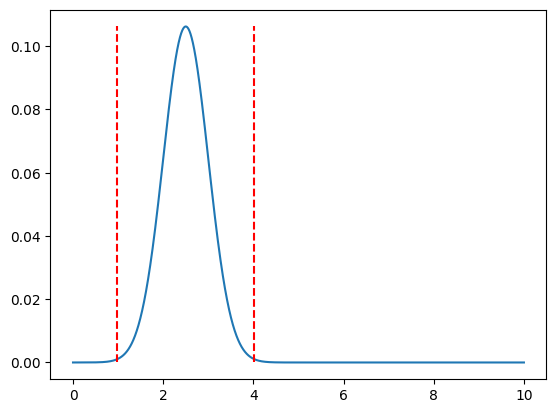

In [68]:
mu, sigma = 2.5, 0.5 # defined for a Gaussian input pulse

# Returns area-normalized Gaussian
def gaussian(mu, sigma, t):
    return np.sqrt(1/(sigma*np.sqrt(np.pi))) * np.exp(-((t-mu)**2) / (2*sigma**2))

### INPUT COHERENT STATE
def alpha_in(t):
    amp = 0.1 # small amplitude
    #amp = 1
    return amp*(gaussian(mu, sigma, t)) 

# Simulation Time
time_final = 10 # total simulation time
N = 5000 # number of time steps
input_photon_number, pulse_duration = get_input_values(alpha_in, time_final, N)

In [69]:
# System Parameters 
C = 100           # cooperativity (higher = more efficient)
gamma = 1       # decay rate
Delta = 700        # detuning

g_se = 1  # coupling strength between |s> and |e>
g_ge = np.sqrt(2*C*gamma) # coupling strength between |g> and |e>

alpha_in_func = alpha_in # input pulse function
template_func = alpha_in # template function for calculating beta(t) (should be same as input pulse for optimal storage)

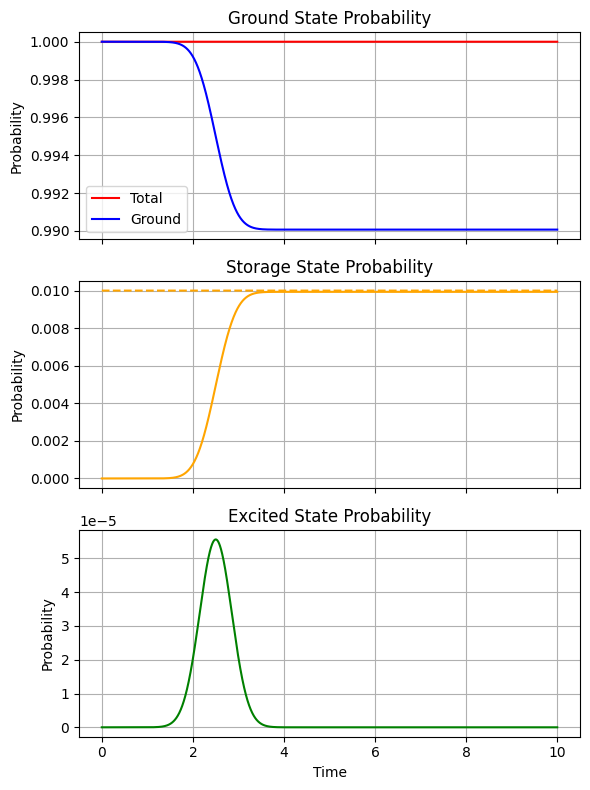

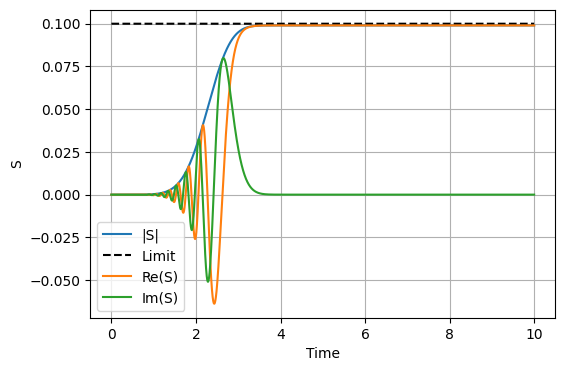

0.009932827144640081


In [70]:
time, S, prob_s, prob_g, prob_e = three_level_simulation(C, gamma, Delta, time_final, T, N, g_se, g_ge, alpha_in_func, template_func)
plot_probs(time, prob_g, prob_e, prob_s, S, input_photon_number)
print(abs(prob_s[-1]))

### Parameter Effects
You can see how changing the parameters $C, \Delta, \gamma$ affect performance below.

- C (efficiency should only be dependent on C): increasing C should increase the efficiency. You will notice that if you decrease cooperativity significantly, you will need to increase the resolution of your time steps (in the code, this corresponds to increasing N).
- $\Delta$ should have no explicit effect on efficiency as we account for large detuning by having $\Delta$ in the numerator of $\beta$. 



In [71]:
C_vals =  np.linspace(0.1, 300, 50)
N=8000
prob_s_vals = []
for i in tqdm(range(len(C_vals))):
    g_ge = np.sqrt(2*C_vals[i]*gamma) # coupling strength between |g> and |e>
    time, S, prob_s, prob_g, prob_e = three_level_simulation(C_vals[i], gamma, Delta, time_final, T, N, g_se, g_ge, alpha_in_func, template_func)
    #print(C_vals[i],abs(prob_s[-1]))
    prob_s_vals.append(abs(prob_s[-1]))

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [03:57<00:00,  4.75s/it]


## Why is my efficiency higher than the C/(1+C)?

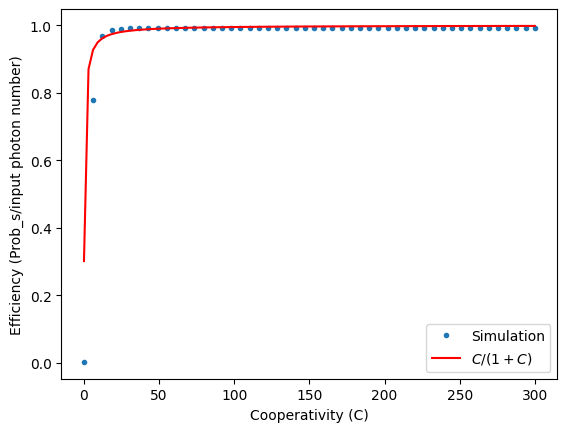

In [72]:
plt.plot(C_vals, np.array(prob_s_vals)/input_photon_number, '.', label='Simulation') # normalize by input photon number (0.01 for amp=0.1)
C_vals_fine =  np.linspace(0.1, 300, 100)
plt.plot(C_vals_fine, np.sqrt(C_vals_fine/(1+C_vals_fine)), color='red', label=r'$C/(1+C)$') # theoretical limit for large detuning
plt.ylabel('Efficiency (Prob_s/input photon number)'); plt.xlabel('Cooperativity (C)')
plt.legend()

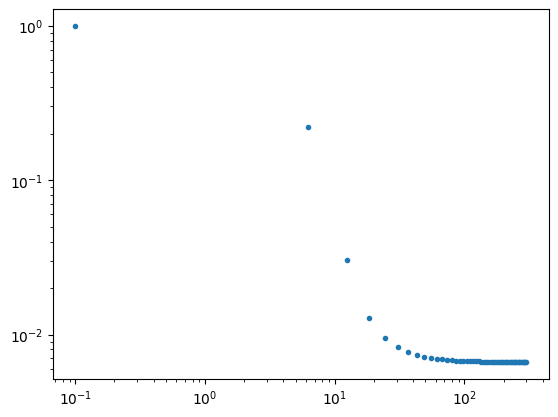

In [ ]:
C_efficiency = np.array(prob_s_vals)/input_photon_number
plt.loglog(C_vals, 1-C_efficiency, '.') 
plt.xlabel('C')
plt.ylabel('1 - C_efficiency')

In [ ]:
detuning_vals =  np.linspace(100, 1000, 50)
prob_s_vals = []
for i in tqdm(range(len(detuning_vals))):
    g_ge = np.sqrt(2*C*gamma) # coupling strength between |g> and |e>
    time, S, prob_s, prob_g, prob_e = three_level_simulation(C, gamma, detuning_vals[i], time_final, T, N, g_se, g_ge, alpha_in_func, template_func)
    prob_s_vals.append(abs(prob_s[-1]))

100%|██████████| 50/50 [02:51<00:00,  3.43s/it]


Text(0.5, 0, 'Detuning')

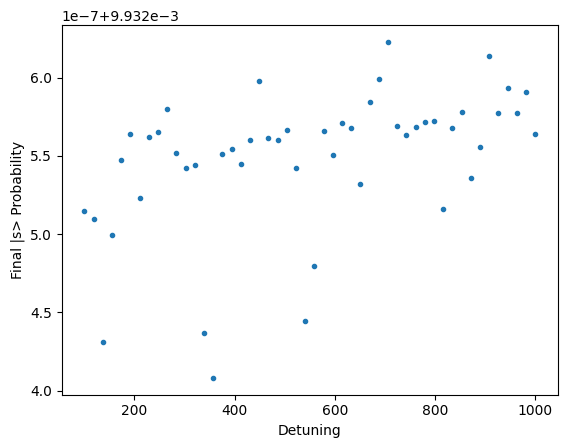

In [16]:
plt.plot(detuning_vals, prob_s_vals, '.')
plt.ylabel('Final |s> Probability'); plt.xlabel('Detuning')

## Testing Other Templates

Observation: the sharper the Lorentzian, the worse the efficiency. 

0.00010000000000000002
Area of alpha: 0.00010000000000000002
Pulse duration: 6.479295859171835


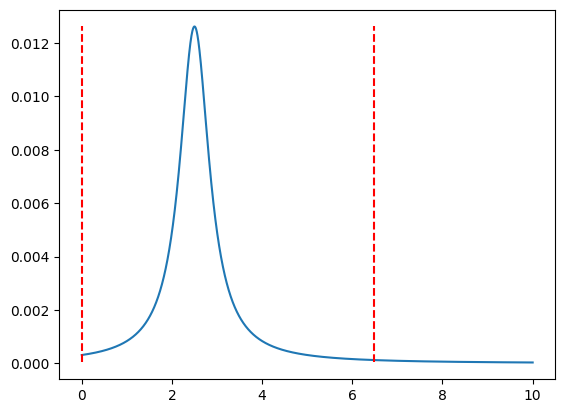

In [66]:
mu, sigma = 2.5, 0.8

# Returns Lorentzian (not area-normalized)
def lorentzian(mu, sigma, t):
    return np.sqrt(sigma/(2*np.pi)) / ((t-mu)**2 + (sigma/2)**2)

area = integrate.simps(lorentzian(mu, sigma, np.linspace(0, time_final, N))**2, np.linspace(0, time_final, N))

### INPUT COHERENT STATE
def alpha_in_other(t):
    amp = np.sqrt(1/area) * 0.01  # small amplitude
    return amp*lorentzian(mu, sigma, t)

print(integrate.simps(alpha_in_other(np.linspace(0, time_final, N))**2, np.linspace(0, time_final, N)))
### SIMULATION PARAMETERS
time_final = 10 # total simulation time
N = 5000 # number of time steps
input_photon_number, T = get_input_values(alpha_in_other, time_final, N)

### SYSTEM PARAMETERS
C = 100         # cooperativity (higher = more efficient)
gamma = 1       # decay rate
Delta = 700     # detuning

g_se = 1  # coupling strength between |s> and |e>
g_ge = np.sqrt(2*C*gamma) # coupling strength between |g> and |e>

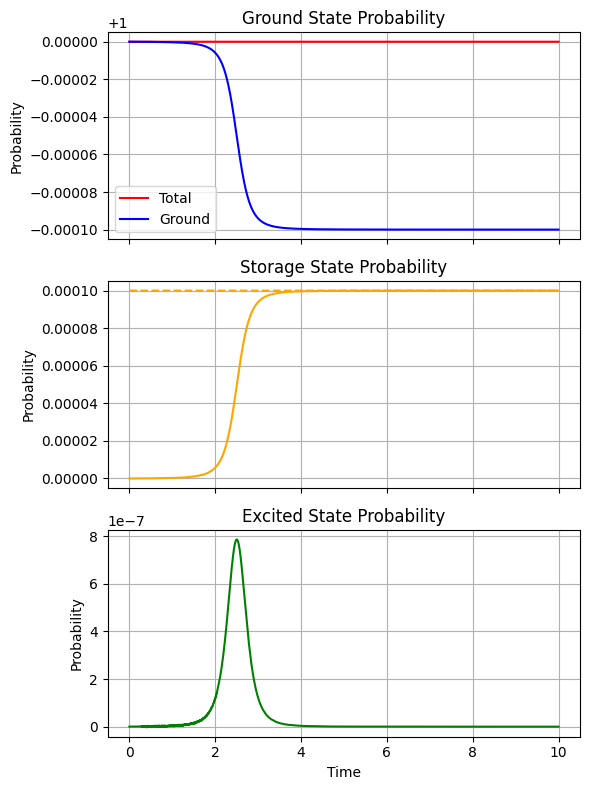

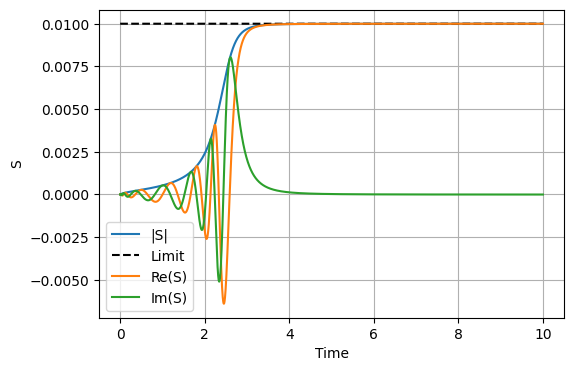

9.997899183395402e-05


In [67]:
time, S, prob_s, prob_g, prob_e = three_level_simulation(C, gamma, Delta, time_final, T, N, g_se, g_ge, alpha_in_other, alpha_in_other)
plot_probs(time, prob_g, prob_e, prob_s, S, input_photon_number)
print(abs(prob_s[-1]))

## Orthogonal Templates
Orthogonal input signal given by a Gaussian times a sin function (see 2LS for more detail). Behaves as expected: the storage state starts to store a little but ultimately rejects the signal because it is orthogonal. Details of this still need to be ironed out as parts of this still confuse me. 

Cases to observe:
- Set the amplitude of alpha_in_orthogonal to 1 (amp = 3, for example). If alpha^2 is 1 instead of 0.01 photons, efficiency/orthogonality changes, limit of alpha being "too large"

Area of alpha: 0.0011059960846405642
Pulse duration: 3.412682536507302


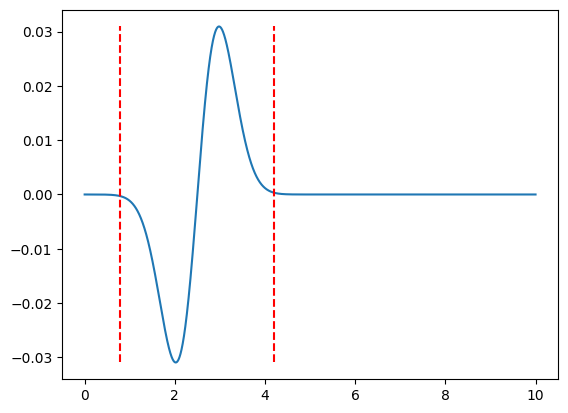

In [51]:
mu, sigma = 2.5, 0.5 # defined for a Gaussian input pulse

### INPUT COHERENT STATE
def alpha_in_orthogonal(t):
    amp = 0.1 # small amplitude
    #amp = 3
    return amp*gaussian(mu, sigma, t) * np.sin(t-mu) # orthogonal to original Gaussian
    
input_photon_number, T = get_input_values(alpha_in_orthogonal, time_final, N)

### SIMULATION PARAMETERS
time_final = 10 # total simulation time
N = 5000 # number of time steps

### SYSTEM PARAMETERS
C = 100           # cooperativity (higher = more efficient)
gamma = 1       # decay rate
Delta = 700        # detuning

g_se = 1  # coupling strength between |s> and |e>
g_ge = np.sqrt(2*C*gamma) # coupling strength between |g> and |e>

C:\Users\bac06\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\matplotlib\cbook\__init__.py:1369: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


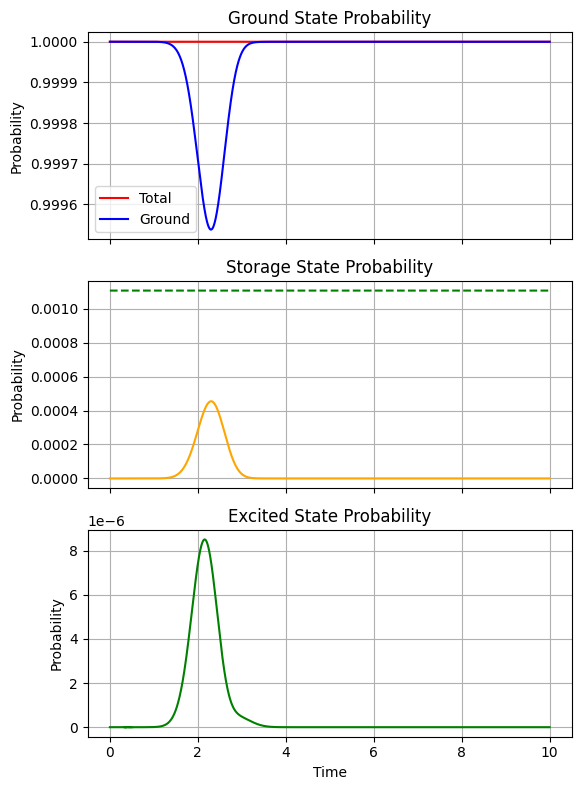

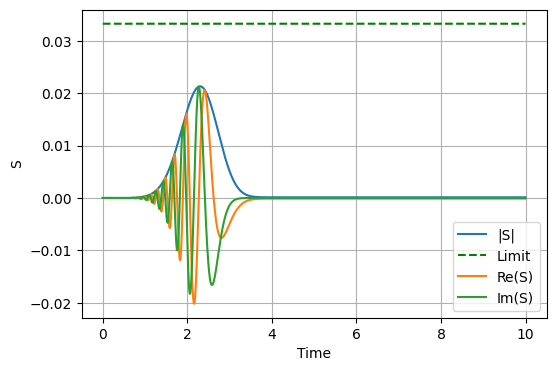

1.043519642252496e-07


In [52]:
time, S, prob_s, prob_g, prob_e = three_level_simulation(C, gamma, Delta, time_final, T, N, g_se, g_ge, alpha_in_orthogonal, alpha_in)
plot_probs(time, prob_g, prob_e, prob_s, S, input_photon_number)
print(abs(prob_s[-1]))

#### Test orthogonal template with es dissipation (S doesn't go to 0). 

In [54]:
#time, S, prob_s, prob_g, prob_e = three_level_simulation(C, gamma, Delta, time_final, T, N, g_se, g_ge, alpha_in_orthogonal, alpha_in)
#plot_probs(time, prob_g, prob_e, prob_s, S, input_photon_number)
#print(abs(prob_s[-1]))

#### For orthogonal template, is the ratio of excited/storage state amplitude affected by decay term?

In [24]:
print(np.real(max(prob_e)/max(prob_s)))

0.018705801920707577


Observe other quantities (see notes): 
- S defines the coherence from $\ket{g}$ to $\ket{s}$. $S^2$ is the coherent storage, which has an analog to purity. 
- The false positive rate (of matching) is given by $P_e - |S|^2$: physical meaning when this is negative??

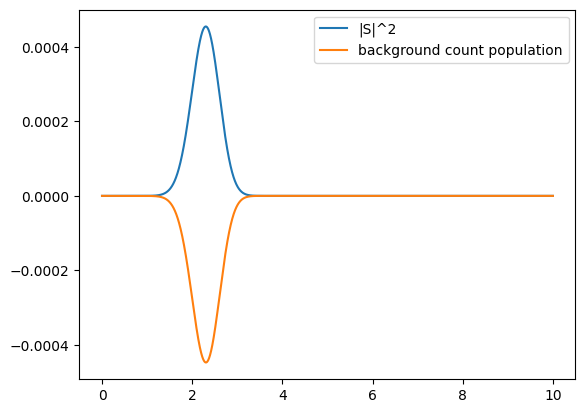

In [48]:
plt.plot(time, abs(S)**2, label='|S|^2')
plt.plot(time, np.real(prob_e) - abs(S)**2, label='background count population')
plt.legend()

### Ideas:
- even vs. odd number of photons on average (2 photons, check efficiency) - I don't really understand this. 
- "Number of overlaps" related to the frequency separation of the signal vs template (for a high frequency template vs slow signal, the templeate will overlap with the signal multiple times, amplitude scaled by the frequency separation) 
- What is up with the cooperativity

## Miscellaneous
### Using Optuna
Performs parallelization and Bayesian optimization. Other options: random sampling.

In [17]:
a_factor_vals =  np.linspace(0.01, 5, 50)
c_factor_vals =  np.linspace(0.01, 5, 50)
Delta_vals = np.linspace(100, 1000, 100)
T, g_se = 10, 1
C = 100
gamma = 1

def objective_optuna(trial):
    c_factor = trial.suggest_float("c_factor", min(c_factor_vals), max(c_factor_vals))
    a_factor = trial.suggest_float("a_factor", min(a_factor_vals), max(a_factor_vals))
    Delta = trial.suggest_float("Delta", min(Delta_vals), max(Delta_vals))
    g_ge = np.sqrt(2*gamma*C)

    time, S, prob_s, prob_g, prob_e = three_level_simulation(a_factor, c_factor, C, gamma, Delta, T, g_se, g_ge, alpha_in)
    return prob_s[-1]

study = optuna.create_study(direction="maximize")
study.optimize(objective_optuna, n_trials=100) # n_jobs=-1
print(study.best_params)
print(study.best_value)

[I 2026-03-25 10:41:07,757] A new study created in memory with name: no-name-064c327d-20f0-4f9d-a529-aef7189021d3
C:\Users\bac06\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\optuna\study\_tell.py:65: ComplexWarning:

Casting complex values to real discards the imaginary part

C:\Users\bac06\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\optuna\study\_tell.py:69: ComplexWarning:

Casting complex values to real discards the imaginary part

C:\Users\bac06\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\optuna\study\_tell.py:166: ComplexWarning:

Casting complex values to real discards the imaginary part

[I 2026-03-25 10:41:11,757] Trial 0 finished with value: 7.201048793642333e-05 and parameters: {'c_factor': 2.658617121556094, 'a_factor': 4.346071241543307, '

{'c_factor': 0.9868926696860765, 'a_factor': 0.9076143358094861, 'Delta': 731.6112717823485}
0.009817440314894654


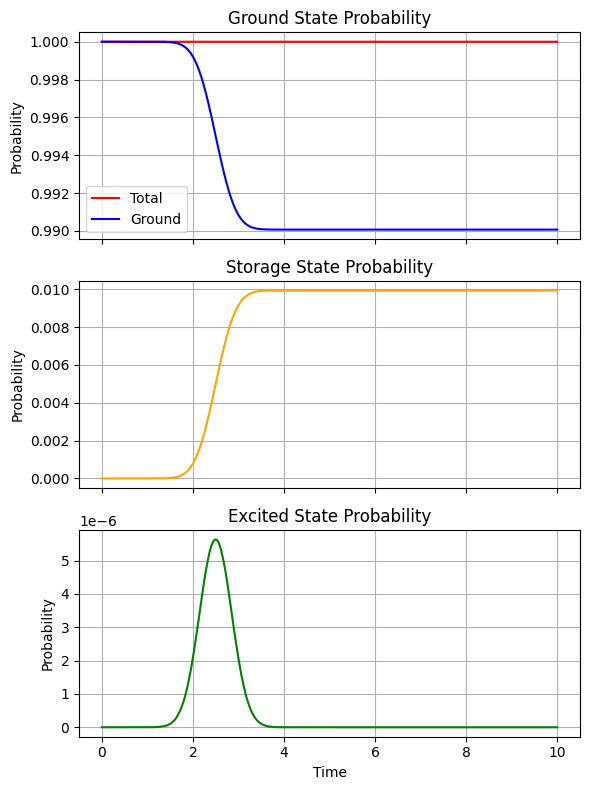

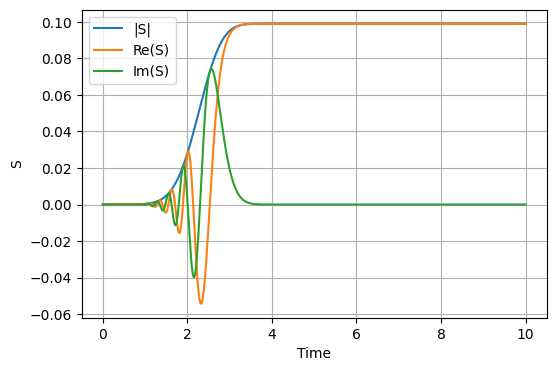

(0.009933456912511462-1.921353855328271e-18j)


In [ ]:
T, g_se = 10, 1
C = 100
gamma = 1
g_ge = np.sqrt(2*gamma*C)
c_factor = 1 #study.best_params['c_factor']
a_factor = 1 #study.best_params['a_factor']
Delta = 5000 # study.best_params['Delta']

time, S, prob_s, prob_g, prob_e = three_level_simulation(a_factor, c_factor, C, gamma, Delta, T, g_se, g_ge, alpha_in)
plot_probs(time, prob_g, prob_e, prob_s, S)
print(prob_s[-1])

In [ ]:
#plot_contour(study, params=["a_factor", "C"])
#plot_optimization_history(study).show()
#plot_param_importances(study).show()